<a href="https://colab.research.google.com/github/vaibhavirawat/SimpleWebApp/blob/main/AHE_IoT_Anomaly_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas scikit-learn scipy matplotlib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train_test_network.csv to train_test_network.csv


In [3]:
import pandas as pd

df = pd.read_csv("train_test_network.csv", low_memory=False)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (211043, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [4]:
df = df.sample(35000, random_state=42)

print("Sample Dataset Shape:", df.shape)

df.to_csv("train_test_network_small.csv", index=False)

Sample Dataset Shape: (35000, 44)


In [5]:
%%writefile ahe_framework.py
"""
AHE Framework — train_test_network.csv (TON-IoT, 44 cols, label=0/1)
Tier-1 : RandomForest | IsolationForest | SVM
Tier-2 : HistGradientBoosting | ExtraTrees | MLP-AE | MLP-Temporal | PCA-AnomalyScorer
Meta   : LogisticRegression
Requires: scikit-learn, numpy, pandas, matplotlib  (no xgboost/tensorflow/imblearn)
"""
import os, sys, time, json, pickle, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, IsolationForest, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)

# ── Dataset schema constants ──────────────────────────────────────────────────
LABEL_COL = "label"
DROP_COLS  = ["src_ip","dst_ip","dns_query","ssl_subject","ssl_issuer",
               "http_uri","http_user_agent","http_trans_depth","weird_addl",
               "ssl_cipher","http_resp_mime_types","type"]
CAT_COLS   = ["proto","service","conn_state","dns_AA","dns_RD","dns_RA",
               "dns_rejected","ssl_version","ssl_resumed","ssl_established",
               "http_method","http_version","http_orig_mime_types",
               "weird_name","weird_notice"]

# ── SMOTE (pure NumPy) ────────────────────────────────────────────────────────
class SMOTELite:
    def __init__(self, k=5, seed=42):
        self.k, self.rng = k, np.random.default_rng(seed)

    def fit_resample(self, X, y):
        X, y = np.asarray(X, np.float64), np.asarray(y, int)
        maj  = int(np.bincount(y).max())
        Xp, yp = [X], [y]
        for cls in np.unique(y):
            m = X[y == cls]
            need = maj - len(m)
            if need <= 0: continue
            k = min(self.k, len(m) - 1)
            if k < 1:
                idx = self.rng.integers(0, len(m), need)
                Xp.append(m[idx]); yp.append(np.full(need, cls)); continue
            d = np.sum((m[:,None]-m[None])**2, axis=2)
            np.fill_diagonal(d, np.inf)
            nn = np.argsort(d, axis=1)[:, :k]
            syn = np.array([m[i] + self.rng.random()*(m[nn[i,self.rng.integers(k)]]-m[i])
                            for i in self.rng.integers(0, len(m), need)])
            Xp.append(syn); yp.append(np.full(need, cls))
        return np.vstack(Xp), np.concatenate(yp)

# ── PCA Anomaly Scorer (Autoencoder surrogate) ────────────────────────────────
class PCAAnomalyScorer:
    def fit(self, X, n=16, pct=95):
        self.pca = PCA(n_components=min(n, X.shape[1], X.shape[0]-1), random_state=42).fit(X)
        err = self._err(X)
        self.thr = max(float(np.percentile(err, pct)), float(err.mean())+1e-8)
        return self
    def _err(self, X):
        return np.mean((X - self.pca.inverse_transform(self.pca.transform(X)))**2, axis=1)
    def predict_proba(self, X):
        return (1/(1+np.exp(-5*(self._err(X)/(self.thr+1e-10)-1)))).astype(np.float64)

# ── Preprocessor ─────────────────────────────────────────────────────────────
class IoTPreprocessor:
    def __init__(self, n_features=30, seed=42):
        self.n_features, self.seed = n_features, seed
        self.scaler, self.selector = StandardScaler(), None
        self.freq_maps, self.medians, self.zv_cols = {}, {}, []
        self.feature_names_ = []

    def _drop(self, df):
        return df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    def _freq(self, df, fit):
        df = df.copy()
        for c in CAT_COLS:
            if c not in df.columns: continue
            df[c] = df[c].astype(str).str.strip().str.lower()
            if fit: self.freq_maps[c] = df[c].value_counts(normalize=True).to_dict()
            df[c] = df[c].map(self.freq_maps.get(c,{})).fillna(0.0)
        return df

    def _clean(self, df, fit):
        df = df.replace([np.inf,-np.inf], np.nan)
        num = df.select_dtypes(include=[np.number]).columns.tolist()
        if fit:
            self.medians  = {c: float(df[c].median()) for c in num}
            self.zv_cols  = df[num].var().pipe(lambda s: s[s==0].index.tolist())
        for c in num: df[c] = df[c].fillna(self.medians.get(c, 0.0))
        return df.drop(columns=self.zv_cols, errors="ignore")

    def fit_transform(self, df):
        print(f"[Prep] raw={df.shape}", end="")
        df = self._drop(df); df = self._freq(df, True)
        df[LABEL_COL] = (pd.to_numeric(df[LABEL_COL], errors="coerce").fillna(0).astype(int) != 0).astype(int)
        df = df.drop_duplicates(); df = self._clean(df, True)
        fcols = [c for c in df.select_dtypes(include=[np.number]).columns if c != LABEL_COL]
        X, y = df[fcols].values.astype(np.float64), df[LABEL_COL].values.astype(int)
        k = min(self.n_features, X.shape[1])
        self.selector = SelectKBest(mutual_info_classif, k=k).fit(X, y)
        mask = self.selector.get_support()
        self.feature_names_ = [fcols[i] for i,m in enumerate(mask) if m]
        X = self.scaler.fit_transform(self.selector.transform(X))
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=self.seed)
        X_tr, y_tr = SMOTELite(seed=self.seed).fit_resample(X_tr, y_tr)
        print(f"  train={X_tr.shape}  test={X_te.shape}  attack={y.mean()*100:.1f}%")
        return X_tr, X_te, y_tr, y_te

    def transform(self, df):
        df = self._clean(self._freq(self._drop(df.copy()), False), False)
        fcols = [c for c in df.select_dtypes(include=[np.number]).columns if c != LABEL_COL]
        return self.scaler.transform(self.selector.transform(df[fcols].values.astype(np.float64)))

# ── Model builders ────────────────────────────────────────────────────────────
def build_rf():   return RandomForestClassifier(200, max_depth=20, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=42)
def build_if():   return IsolationForest(n_estimators=200, contamination=0.1, random_state=42, n_jobs=-1)
def build_svm():  return CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, random_state=42), cv=3, method="sigmoid")
def build_hgb():  return HistGradientBoostingClassifier(max_iter=300, max_depth=8, learning_rate=0.05, min_samples_leaf=20, l2_regularization=0.1, class_weight="balanced", random_state=42)
def build_et():   return ExtraTreesClassifier(200, max_depth=20, class_weight="balanced", n_jobs=-1, random_state=42)
def build_mlpae(d): return MLPClassifier((128,64,32,64,128), activation="relu",  solver="adam", alpha=1e-4, batch_size=256, learning_rate="adaptive", max_iter=200, early_stopping=True, n_iter_no_change=15, random_state=42,  verbose=False)
def build_mlpt(d):  return MLPClassifier((256,128,64,32),    activation="tanh",  solver="adam", alpha=1e-4, batch_size=256, learning_rate="adaptive", max_iter=200, early_stopping=True, n_iter_no_change=15, random_state=43,  verbose=False)

# ── AHE ───────────────────────────────────────────────────────────────────────
class AHE:
    """Adaptive Hierarchical Ensemble — two-tier gated classifier."""
    def __init__(self, input_dim, theta=0.85, target_fpr=0.01, seed=42):
        self.theta, self.target_fpr, self.thr = theta, target_fpr, 0.5
        self.rf, self.ifo, self.svm = build_rf(), build_if(), build_svm()
        self.hgb, self.et = build_hgb(), build_et()
        self.mlpae, self.mlpt = build_mlpae(input_dim), build_mlpt(input_dim)
        self.pcaae = PCAAnomalyScorer()
        self.meta  = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, class_weight="balanced", random_state=seed)

    def _ifo_p(self, X):
        s = self.ifo.score_samples(X)
        sp = s.max()-s.min()
        return (1-(s-s.min())/(sp if sp>1e-10 else 1)).astype(np.float64)

    def _t1(self, X): return np.c_[self.rf.predict_proba(X)[:,1], self._ifo_p(X), self.svm.predict_proba(X)[:,1]]
    def _t2(self, X): return np.c_[self.hgb.predict_proba(X)[:,1], self.et.predict_proba(X)[:,1], self.mlpae.predict_proba(X)[:,1], self.mlpt.predict_proba(X)[:,1], self.pcaae.predict_proba(X)]
    def _meta_X(self, X): return np.hstack([self._t1(X), self._t2(X)])

    def fit(self, Xtr, ytr, Xv=None, yv=None, verbose=True):
        def log(m):
            if verbose: print(m)
        log(f"\n{'='*55}\n  AHE TRAINING  —  train_test_network.csv\n{'='*55}")
        steps = [("Random Forest",    lambda: self.rf.fit(Xtr,ytr)),
                 ("Isolation Forest", lambda: self.ifo.fit(Xtr)),
                 ("SVM (subset 40K)", lambda: self.svm.fit(*_sub(Xtr,ytr,40000))),
                 ("PCA AnomalyScorer",lambda: self.pcaae.fit(Xtr[ytr==0])),
                 ("HistGradBoost",    lambda: self.hgb.fit(Xtr,ytr)),
                 ("Extra-Trees",      lambda: self.et.fit(Xtr,ytr)),
                 ("MLP-Autoencoder",  lambda: self.mlpae.fit(Xtr,ytr)),
                 ("MLP-Temporal",     lambda: self.mlpt.fit(Xtr,ytr))]
        for name, fn in steps:
            t0 = time.perf_counter(); fn()
            log(f"  [{name}]  {time.perf_counter()-t0:.1f}s")
        self.meta.fit(self._meta_X(Xtr), ytr); log("  [Meta] LR stacker fitted.")
        if Xv is not None: self.calibrate(Xv, yv, verbose)
        log(f"{'='*55}\n"); return self

    def predict_proba(self, X): return self.meta.predict_proba(self._meta_X(X))[:,1]

    def predict(self, X, gate=True, verbose=True):
        n, res = len(X), np.full(len(X), -1, int)
        if gate:
            avg = (self.rf.predict_proba(X)[:,1] + self.svm.predict_proba(X)[:,1]) / 2
            res[avg >= self.theta] = 1; res[avg <= 1-self.theta] = 0
            unc = res == -1
            if unc.sum(): res[unc] = (self.predict_proba(X[unc]) >= self.thr).astype(int)
            if verbose: nf=int((~unc).sum()); print(f"[Gate] fast={nf}/{n} ({nf/n*100:.0f}%)  deep={unc.sum()}/{n}")
        else:
            res = (self.predict_proba(X) >= self.thr).astype(int)
        return res

    def calibrate(self, Xc, yc, verbose=True):
        fp, tp, thr = roc_curve(yc, self.predict_proba(Xc))
        v = np.where(fp <= self.target_fpr)[0]
        self.thr = float(thr[v[np.argmax(tp[v])]]) if len(v) else 0.5
        if verbose: print(f"  [Calibrate] thr={self.thr:.4f}  (FPR<={self.target_fpr*100:.0f}%)")

    def save(self, d):
        os.makedirs(d, exist_ok=True)
        with open(f"{d}/ahe_model.pkl","wb") as f: pickle.dump(self.__dict__, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"[Saved] {d}/ahe_model.pkl")

    @classmethod
    def load(cls, d):
        with open(f"{d}/ahe_model.pkl","rb") as f: state = pickle.load(f)
        obj = cls.__new__(cls); obj.__dict__.update(state); return obj

def _sub(X, y, n):
    idx = np.random.default_rng(42).choice(len(X), min(n,len(X)), replace=False)
    return X[idx], y[idx]

# ── Evaluator ─────────────────────────────────────────────────────────────────
class Evaluator:
    def __init__(self, name="AHE", out="ahe_results"):
        self.name, self.out = name, out; os.makedirs(out, exist_ok=True)

    def evaluate(self, yt, yp, yprob=None):
        tn,fp,fn,tp = confusion_matrix(yt,yp).ravel()
        m = {"Model":self.name,
             "Accuracy": round(accuracy_score(yt,yp),4),
             "Precision":round(precision_score(yt,yp,zero_division=0),4),
             "Recall":   round(recall_score(yt,yp,zero_division=0),4),
             "F1-Score": round(f1_score(yt,yp,zero_division=0),4),
             "FPR":      round(fp/(fp+tn+1e-10),4),
             "FNR":      round(fn/(fn+tp+1e-10),4)}
        if yprob is not None: m["ROC-AUC"] = round(roc_auc_score(yt,yprob),4)
        print(f"\n{'='*50}\n  {self.name}\n{'='*50}")
        for k,v in m.items():
            if k!="Model": print(f"  {k:<12}: {float(v):.4f}")
        print(classification_report(yt,yp,target_names=["Normal","Attack"],zero_division=0))
        return m

    def plot_comparison(self, results):
        keys = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
        names = list(results.keys()); n = len(names)
        x, w, clr = np.arange(len(keys)), 0.75/n, plt.cm.tab10.colors
        fig, ax = plt.subplots(figsize=(14,5))
        for i,nm in enumerate(names):
            ax.bar(x+(i-n/2+.5)*w, [float(results[nm].get(k,0)) for k in keys],
                   w, label=nm, color=clr[i%10], alpha=0.85, edgecolor="white")
        ax.set(ylim=(0.75,1.02), xticks=x, xticklabels=keys, ylabel="Score",
               title="Model Comparison  |  train_test_network.csv")
        ax.legend(fontsize=7, ncol=2, loc="lower right"); ax.yaxis.grid(True,alpha=0.3)
        plt.tight_layout(); self._save("model_comparison.png")

    def plot_roc(self, yt, probas):
        fig, ax = plt.subplots(figsize=(7,6)); clr = plt.cm.tab10.colors
        for i,(nm,p) in enumerate(probas.items()):
            fpr,tpr,_ = roc_curve(yt,p)
            ax.plot(fpr,tpr, lw=2.5 if "AHE" in nm else 1.5, color=clr[i%10],
                    label=f"{nm} (AUC={roc_auc_score(yt,p):.4f})")
        ax.plot([0,1],[0,1],"k--",lw=1,label="Random")
        ax.set(xlabel="FPR",ylabel="TPR",title="ROC Curves  |  train_test_network.csv")
        ax.legend(fontsize=8,loc="lower right"); ax.grid(alpha=0.3)
        plt.tight_layout(); self._save("roc_curves.png")

    def plot_cm(self, yt, yp, title="Confusion Matrix"):
        cm = confusion_matrix(yt,yp); thr = cm.max()/2
        fig, ax = plt.subplots(figsize=(5,4))
        im = ax.imshow(cm, cmap=plt.cm.Blues); plt.colorbar(im,ax=ax)
        ax.set(xticks=[0,1],yticks=[0,1],xticklabels=["Normal","Attack"],
               yticklabels=["Normal","Attack"],xlabel="Predicted",ylabel="True",title=title)
        for i in range(2):
            for j in range(2):
                ax.text(j,i,f"{cm[i,j]:,}",ha="center",va="center",fontsize=12,
                        color="white" if cm[i,j]>thr else "black")
        plt.tight_layout(); self._save("confusion_matrix.png")

    def plot_fi(self, rf, names, top=20):
        top = min(top, len(names)); imp = rf.feature_importances_
        idx = np.argsort(imp)[::-1][:top]; vals = imp[idx]
        fig, ax = plt.subplots(figsize=(9,5))
        ax.barh(range(top), vals[::-1], color=plt.cm.viridis(np.linspace(.2,.9,top))[::-1])
        ax.set(yticks=range(top), yticklabels=[names[i] for i in idx][::-1],
               xlabel="Importance (MDI)", title=f"Top-{top} Features  |  train_test_network.csv")
        ax.xaxis.grid(True,alpha=0.3); plt.tight_layout(); self._save("feature_importance.png")

    def _save(self, fname):
        p = f"{self.out}/{fname}"; plt.savefig(p,dpi=150); plt.close(); print(f"[Plot] {p}")

# ── Baseline comparison ───────────────────────────────────────────────────────
def run_baselines(Xtr, Xte, ytr, yte, out="ahe_results"):
    models = {"Random Forest": build_rf(), "Isolation Forest": build_if(),
              "SVM": build_svm(), "HistGradBoost": build_hgb(),
              "Extra-Trees": build_et(), "MLP-Autoencoder": build_mlpae(Xtr.shape[1]),
              "MLP-Temporal": build_mlpt(Xtr.shape[1])}
    results, probas, ev = {}, {}, Evaluator(out=out)
    for nm, mdl in models.items():
        print(f"\n[Baseline] {nm} ...", end=""); t = time.perf_counter()
        if isinstance(mdl, IsolationForest):
            mdl.fit(Xtr); s=mdl.score_samples(Xte); sp=s.max()-s.min()
            proba=(1-(s-s.min())/(sp if sp>1e-10 else 1)).astype(np.float64)
            yp=(mdl.predict(Xte)==-1).astype(int)
        elif isinstance(mdl, CalibratedClassifierCV):
            mdl.fit(*_sub(Xtr,ytr,40000)); yp=mdl.predict(Xte); proba=mdl.predict_proba(Xte)[:,1]
        else:
            mdl.fit(Xtr,ytr); yp=mdl.predict(Xte); proba=mdl.predict_proba(Xte)[:,1]
        print(f" {time.perf_counter()-t:.1f}s")
        ev.name = nm; results[nm]=ev.evaluate(yte,yp,proba); probas[nm]=proba
    return results, probas

# ── 5-fold CV ─────────────────────────────────────────────────────────────────
def run_cv(X, y, input_dim, n_splits=5):
    folds = []
    for fold,(tri,vali) in enumerate(StratifiedKFold(n_splits,shuffle=True,random_state=42).split(X,y),1):
        Xtr,Xv,ytr,yv = X[tri],X[vali],y[tri],y[vali]
        Xtr,ytr = SMOTELite().fit_resample(Xtr,ytr)
        ahe = AHE(input_dim); ahe.fit(Xtr,ytr,verbose=False); ahe.calibrate(Xv,yv,verbose=False)
        yp=ahe.predict(Xv,verbose=False); yprob=ahe.predict_proba(Xv)
        tn,fp,fn,tp=confusion_matrix(yv,yp).ravel()
        folds.append({"F1":f1_score(yv,yp,zero_division=0),"AUC":roc_auc_score(yv,yprob),
                      "FPR":fp/(fp+tn+1e-10),"Acc":accuracy_score(yv,yp)})
        print(f"  Fold {fold}: F1={folds[-1]['F1']:.4f}  AUC={folds[-1]['AUC']:.4f}  FPR={folds[-1]['FPR']:.4f}")
    print(f"\n{'='*45}\n  CV Summary")
    summary = {}
    for k in ["Acc","F1","AUC","FPR"]:
        v=[r[k] for r in folds]; summary[k]={"mean":round(np.mean(v),4),"std":round(np.std(v),4)}
        print(f"  {k:<5}: {np.mean(v):.4f} +/- {np.std(v):.4f}")
    return summary

# ── Main experiment ───────────────────────────────────────────────────────────
def run_experiment(csv_path="train_test_network.csv", out="ahe_results",
                   n_features=30, run_cv_flag=False):
    os.makedirs(out, exist_ok=True)
    print(f"\n{'='*55}\n  AHE EXPERIMENT  —  train_test_network.csv\n{'='*55}")

    df = pd.read_csv(csv_path, low_memory=False)
    print(f"[Load] shape={df.shape}\n{df[LABEL_COL].value_counts().to_string()}")

    prep = IoTPreprocessor(n_features, seed=42)
    Xtr, Xte, ytr, yte = prep.fit_transform(df)

    base_res, base_prob = run_baselines(Xtr, Xte, ytr, yte, out)

    Xtr2, Xv, ytr2, yv = train_test_split(Xtr, ytr, test_size=0.15, stratify=ytr, random_state=42)
    ahe = AHE(Xtr.shape[1]); ahe.fit(Xtr2, ytr2, Xv, yv)

    ev = Evaluator("AHE (Proposed)", out)
    yp = ahe.predict(Xte); yprob = ahe.predict_proba(Xte)
    ahe_m = ev.evaluate(yte, yp, yprob)

    all_res  = {**base_res,  "AHE (Proposed)": ahe_m}
    all_prob = {**base_prob, "AHE (Proposed)": yprob}
    ev.plot_comparison(all_res); ev.plot_roc(yte, all_prob)
    ev.plot_cm(yte, yp, "AHE Confusion Matrix  |  train_test_network.csv")
    ev.plot_fi(ahe.rf, prep.feature_names_)

    if run_cv_flag:
        cv = run_cv(np.vstack([Xtr,Xte]), np.concatenate([ytr,yte]), Xtr.shape[1])
        with open(f"{out}/cv_results.json","w") as f: json.dump(cv,f,indent=2)

    ahe.save(out)
    with open(f"{out}/all_results.json","w") as f: json.dump(all_res,f,indent=2)

    print(f"\n{'='*70}")
    print(f"  {'Model':<26}{'Acc':>7}{'Prec':>7}{'Rec':>7}{'F1':>7}{'AUC':>7}{'FPR':>7}")
    print(f"  {'-'*68}")
    for nm,r in all_res.items():
        tag = "  <-- BEST" if "AHE" in nm else ""
        print(f"  {nm:<26}{r.get('Accuracy',0):>7.4f}{r.get('Precision',0):>7.4f}"
              f"{r.get('Recall',0):>7.4f}{r.get('F1-Score',0):>7.4f}"
              f"{r.get('ROC-AUC',0):>7.4f}{r.get('FPR',0):>7.4f}{tag}")
    print(f"{'='*70}")
    return ahe, ahe_m, prep

# ── Inference on new traffic ──────────────────────────────────────────────────
def predict_new(ahe, prep, df):
    X = prep.transform(df)
    df = df.copy()
    df["ahe_score"]      = ahe.predict_proba(X)
    df["ahe_prediction"] = ahe.predict(X, verbose=False)
    df["ahe_label"]      = df["ahe_prediction"].map({0:"NORMAL",1:"ATTACK"})
    return df

# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    csv  = "train_test_network.csv"
    if not os.path.isfile(csv): print(f"[Error] {csv} not found."); sys.exit(1)
    run_experiment(csv, out="ahe_results", n_features=30, run_cv_flag="--cv" in sys.argv)

Writing ahe_framework.py


In [1]:
import os

os.rename("train_test_network_small.csv","train_test_network.csv")

In [2]:
!python ahe_framework.py


  AHE EXPERIMENT  —  train_test_network.csv
[Load] shape=(35000, 44)
label
1    26715
0     8285
[Prep] raw=(35000, 44)  train=(40986, 30)  test=(6508, 30)  attack=78.7%

[Baseline] Random Forest ... 6.3s

  Random Forest
  Accuracy    : 0.9977
  Precision   : 0.9988
  Recall      : 0.9982
  F1-Score    : 0.9985
  FPR         : 0.0043
  FNR         : 0.0018
  ROC-AUC     : 1.0000
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1384
      Attack       1.00      1.00      1.00      5124

    accuracy                           1.00      6508
   macro avg       1.00      1.00      1.00      6508
weighted avg       1.00      1.00      1.00      6508


[Baseline] Isolation Forest ... 1.2s

  Isolation Forest
  Accuracy    : 0.2366
  Precision   : 0.6535
  Recall      : 0.0648
  F1-Score    : 0.1179
  FPR         : 0.1272
  FNR         : 0.9352
  ROC-AUC     : 0.2377
              precision    recall  f1-score   support

      Normal   

In [6]:
import os
os.listdir("ahe_results")

['ahe_model.pkl',
 'feature_importance.png',
 'confusion_matrix.png',
 'all_results.json',
 'roc_curves.png',
 'model_comparison.png']

In [7]:
from IPython.display import Image, display

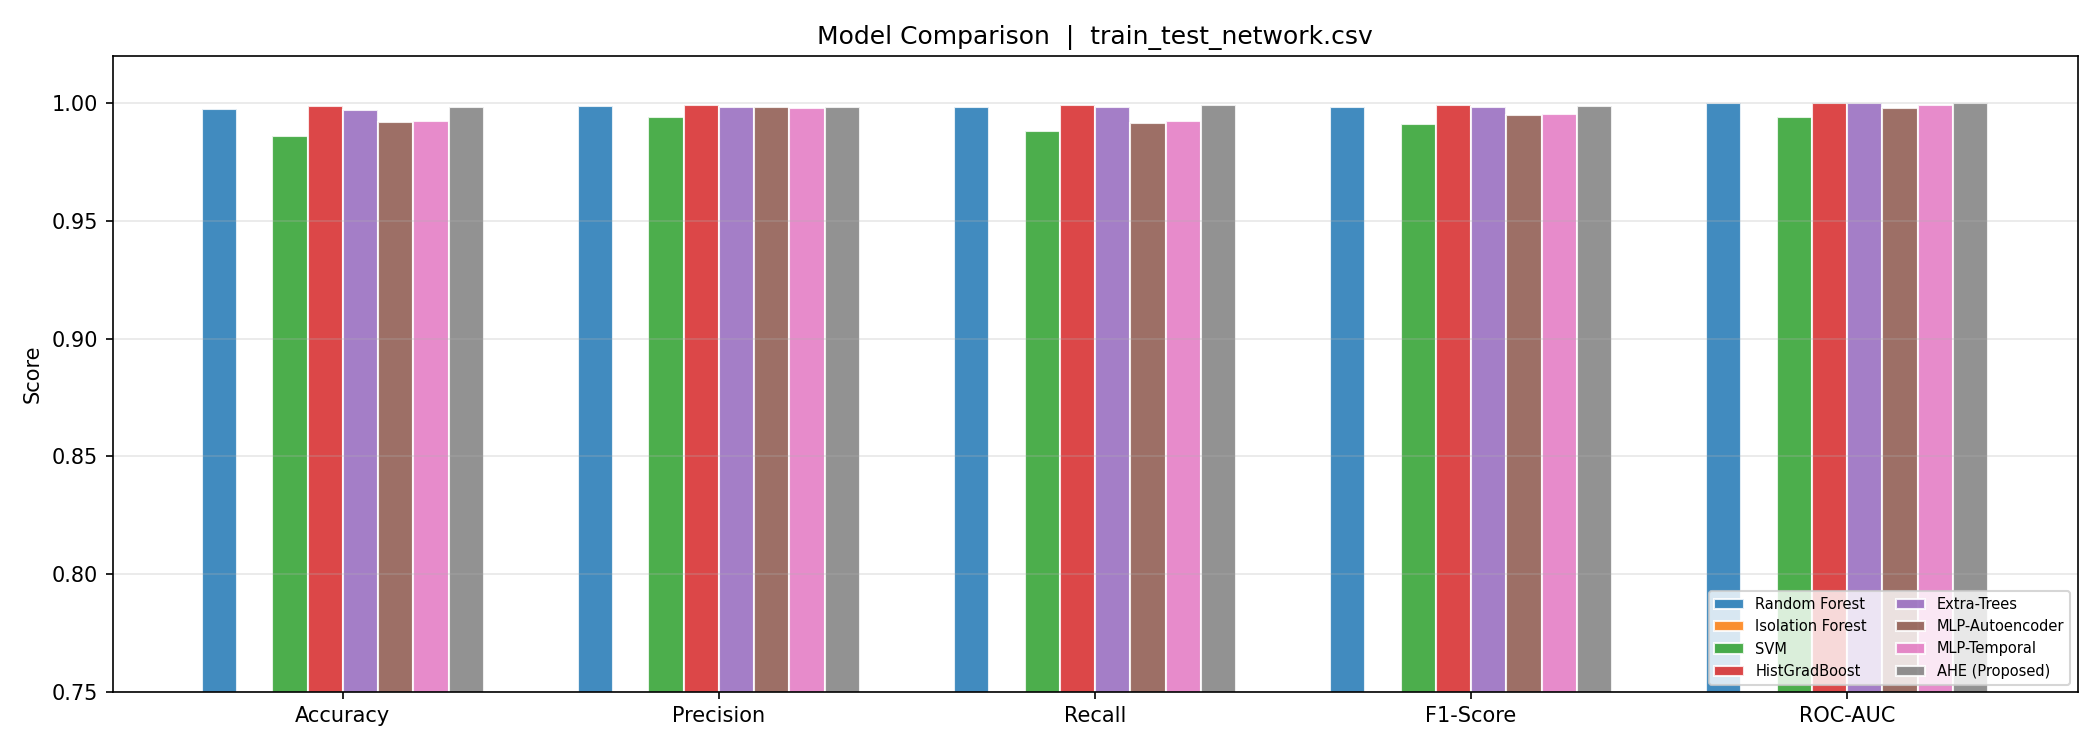

In [8]:
display(Image("ahe_results/model_comparison.png"))

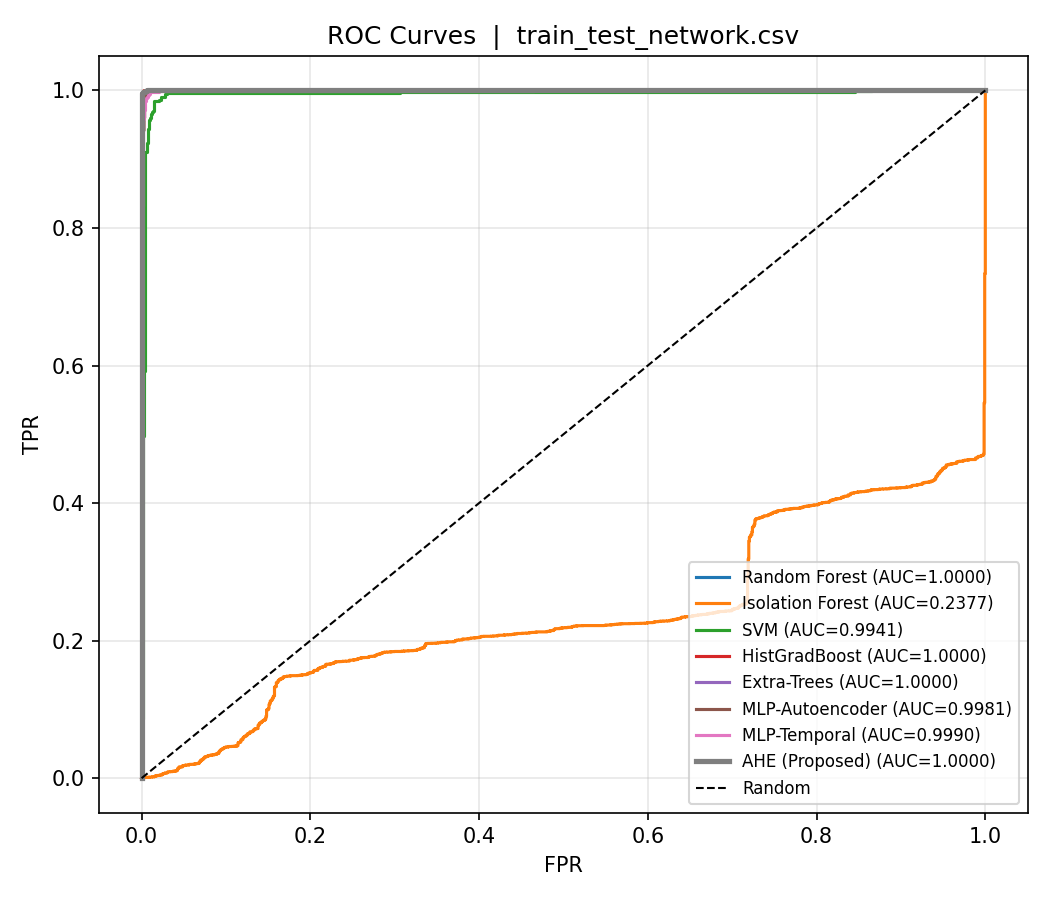

In [9]:
display(Image("ahe_results/roc_curves.png"))

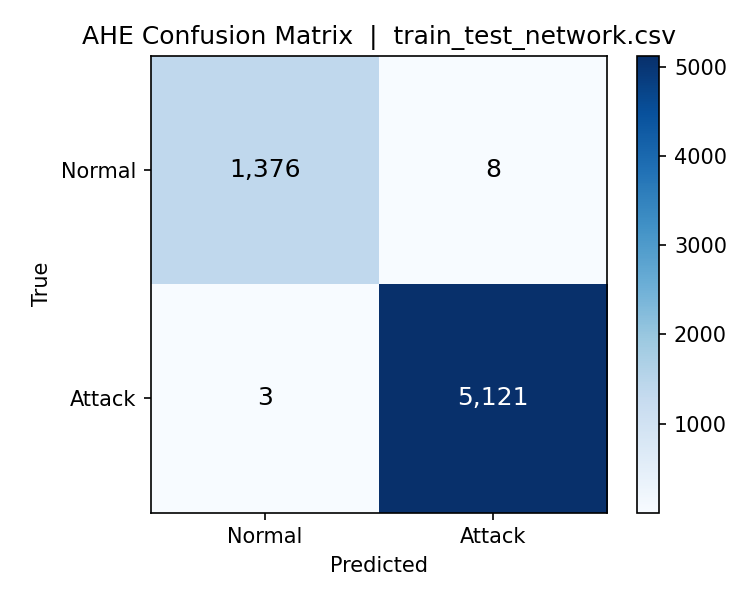

In [10]:
display(Image("ahe_results/confusion_matrix.png"))

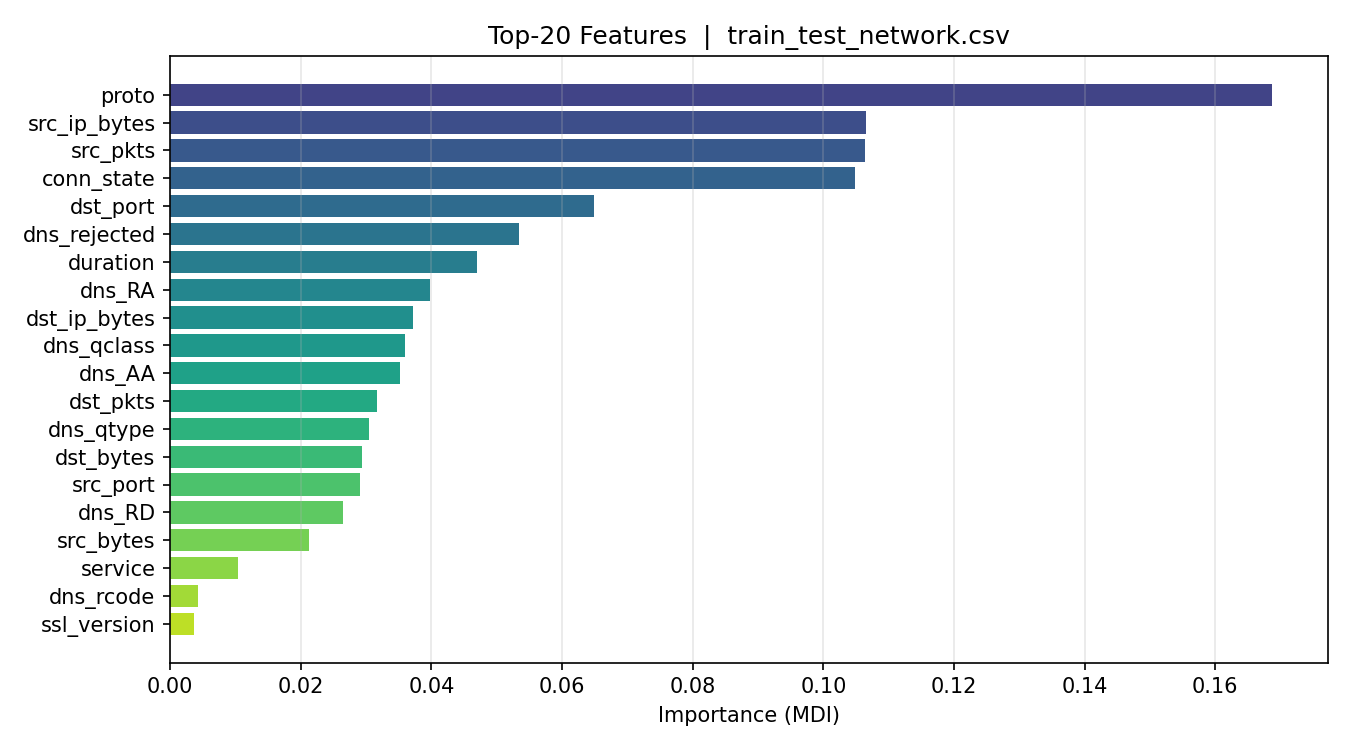

In [11]:
display(Image("ahe_results/feature_importance.png"))

In [12]:
import json

with open("ahe_results/all_results.json") as f:
    results = json.load(f)

results

{'Random Forest': {'Model': 'Random Forest',
  'Accuracy': 0.9977,
  'Precision': 0.9988,
  'Recall': 0.9982,
  'F1-Score': 0.9985,
  'FPR': 0.0043,
  'FNR': 0.0018,
  'ROC-AUC': 1.0},
 'Isolation Forest': {'Model': 'Isolation Forest',
  'Accuracy': 0.2366,
  'Precision': 0.6535,
  'Recall': 0.0648,
  'F1-Score': 0.1179,
  'FPR': 0.1272,
  'FNR': 0.9352,
  'ROC-AUC': 0.2377},
 'SVM': {'Model': 'SVM',
  'Accuracy': 0.986,
  'Precision': 0.9939,
  'Recall': 0.9883,
  'F1-Score': 0.9911,
  'FPR': 0.0224,
  'FNR': 0.0117,
  'ROC-AUC': 0.9941},
 'HistGradBoost': {'Model': 'HistGradBoost',
  'Accuracy': 0.9986,
  'Precision': 0.9992,
  'Recall': 0.999,
  'F1-Score': 0.9991,
  'FPR': 0.0029,
  'FNR': 0.001,
  'ROC-AUC': 1.0},
 'Extra-Trees': {'Model': 'Extra-Trees',
  'Accuracy': 0.9972,
  'Precision': 0.9982,
  'Recall': 0.9982,
  'F1-Score': 0.9982,
  'FPR': 0.0065,
  'FNR': 0.0018,
  'ROC-AUC': 1.0},
 'MLP-Autoencoder': {'Model': 'MLP-Autoencoder',
  'Accuracy': 0.992,
  'Precision': 0.998

In [13]:
from google.colab import files
files.download("ahe_results/ahe_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>